### Confluence/Jira → Pre-Processing → Policy-Retrieval (RAG) → Compliance-Engine → Red-Flag+XAI → Remediation-Generator → Human-in-the-Loop-Gate → Write-Back+Audit-Log

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report
)

### The dataset:- 
- Keep in mind that we have a columns called ``is_compliant``.
- If the value in this column is `0`, it is a red flag, if not, project is compliant.

In [3]:
df = pd.read_csv("../../../data/proposals_1000_EN.csv")
df.dtypes

proposal_id        str
project            str
issue_type         str
ai_method          str
description        str
red_flags          str
n_red_flags      int64
is_compliant     int64
grounded_flag    int64
label              str
word_count       int64
dtype: object

### As mentioned above:- 
- Here I am switching the values for ``is_compliant``.
- Why I do this is because of the ````EVALUATION METRICS FUNCTION````.
    - So the thing with these functions is that they have a hidden default where in they will specifically target the 1 value as something they are trying to catch. 
    - So if I flip the value, I get better results which will be explained below.

In [4]:
y=1-df["is_compliant"]

In [5]:
# What we will use to predict thee y defined above is:- 
X_text=df["description"]

### TF-IDF:- 
- Vectorizing the X_text variable which contains all of the rows from the column description.

In [9]:
vectorizer=TfidfVectorizer(stop_words="english", max_features=2000)
X_tfidf=vectorizer.fit_transform(X_text)

In [10]:
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

### Normalizing:- 

In [11]:
X_normalized=normalize(X_reduced)

### Trying number of clusters:-  (k_values)
- Here, we do not have any specific rules.
- You can define as many clusters as you want.
- I chose to go with range between 2 and 9 because:- 
    - We have 2 classes. (Red Flags and Not red flags)
    - Our RAI Catalogue has 9 policies.
- We can obviously go higher than 9 but not less than 2.
- Not less than 2 becasue:- 
    - Then we would only have 1 cluster. (NOT HELPFUL AT ALL)
- We will also initialize an empty list where we will store the clusters. (AS LIST)

In [12]:
inertias=[]
k_values=list(range(2,9))

### The for loop:- 
- This for loop will help us try various k starting from 2 and will go on till a value less than 9.
- Then for KMeans, we define n_clusters as i and `i will contain the number of clusters as list from k_values`.
- Then we fit. (Only fit). Because:- 
    - We are not going to be using any of the transformed values by k-means downstream.
    - Hence we only use fit for the KMeans object.
- Then we append to the empty list created in the previous step using `intertia_`
- n_init is the number of times the algorithm will run internally each time starting from a different center position and keep whichever run produces the best (lowest) value for inertia.

In [13]:
for i in k_values:
    km=KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_normalized)
    inertias.append(km.inertia_)

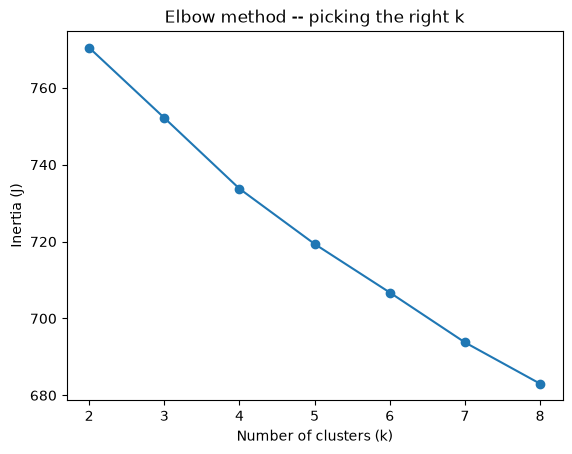

In [14]:
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (J)")
plt.title("Elbow method -- picking the right k")
plt.show()

In [15]:
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df["cluster"] = km_final.fit_predict(X_normalized)

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_normalized)